In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from ipywidgets import interactive, HBox, VBox, widgets

# Generate synthetic data
X, y = make_blobs(n_samples=20, centers=2, random_state=6, cluster_std=[1.5, 1.5])

<Axes: >

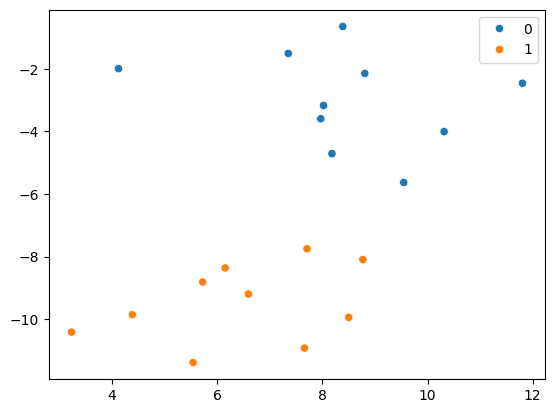

In [2]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue = y)

## SVM Hard Margin Using Hinge Loss and gradient descent

In [3]:
import numpy as np
import plotly.graph_objects as go
from IPython.display import clear_output
import time
from sklearn.datasets import make_blobs

class LinearSVM:
    # Constructor with initialization of hyperparameters and model parameters
    def __init__(self, learning_rate=0.01, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate  # Learning rate for the gradient descent
        self.lambda_param = lambda_param  # Regularization strength
        self.n_iters = n_iters  # Number of iterations for training
        self.w = None  # Weight vector
        self.b = None  # Bias term

    # Method to fit the SVM to the data
    def fit(self, X, y):
        n_samples, n_features = X.shape  # Get the number of samples and features
        y_ = np.where(y <= 0, -1, 1)  # Convert binary labels to -1 and 1
        self.w = np.random.randn(n_features)  # Initialize weights randomly
        self.b = 0  # Initialize bias to zero

        # Training loop
        for i in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1  # Margin condition
                if condition:
                    # Update weights for correctly classified points with margin constraint satisfied
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for misclassified points or points within the margin
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]
            # Visualize every iteration
            if i % 1 == 0:
                self.visualize(X, y_, i)
                time.sleep(0.1)  # Delay for visualization

    # Visualization method using Plotly
    def visualize(self, X, y, iteration):
        clear_output(wait=True)
        fig = go.Figure()

        # Plot data points with colors based on labels
        fig.add_trace(go.Scatter(x=X[:, 0], y=X[:, 1], mode='markers',
                                 marker=dict(color=['blue' if label == 1 else 'red' for label in y], size=10),
                                 name='Data Points'))

        # Calculate and plot decision boundary and margins
        x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
        y_values = -(self.w[0] * x_values + self.b) / self.w[1]
        margin = 1 / np.linalg.norm(self.w)
        y_margin_up = y_values + margin
        y_margin_down = y_values - margin
        fig.add_trace(go.Scatter(x=x_values, y=y_values, mode='lines', name='Decision Boundary'))
        fig.add_trace(go.Scatter(x=x_values, y=y_margin_up, mode='lines', line=dict(dash='dot'), name='Upper Margin'))
        fig.add_trace(go.Scatter(x=x_values, y=y_margin_down, mode='lines', line=dict(dash='dot'), name='Lower Margin'))

        # Highlight support vectors
        distances = y * (np.dot(X, self.w) + self.b)
        support_vectors = X[np.abs(distances - 1) <= 0.05]
        fig.add_trace(go.Scatter(x=support_vectors[:, 0], y=support_vectors[:, 1], mode='markers',
                                 marker=dict(color='yellow', size=12, line=dict(color='black', width=2)),
                                 name='Support Vectors'))

        # Update plot layout
        fig.update_layout(title=f'Iteration {iteration + 1}', xaxis_title='Feature 1', yaxis_title='Feature 2',
                          showlegend=True)
        fig.show()

# Encode synthetic data for SVM
y = np.where(y == 0, -1, 1)

# Create and fit the SVM model
svm = LinearSVM(learning_rate=0.005, lambda_param=0.01, n_iters=1000)
svm.fit(X, y)


## Linear SVM Implementation

This implementation of a linear SVM uses gradient descent for optimization. Here are the main components:

### Constructor: `__init__(self, learning_rate, lambda_param, n_iters)`
Initializes the SVM with the specified learning rate, regularization parameter (`lambda_param`), and number of iterations. It also sets up the initial values for weights (`self.w`) and bias (`self.b`).

### Fit Method: `fit(self, X, y)`
Fits the SVM model to the training data `X` with labels `y`. The labels are converted to -1 or 1. It performs the following steps:
- Initialize weights randomly and bias to zero.
- Iteratively update the weights and bias using gradient descent, based on the margin conditions.
- Optionally, visualize the decision boundary every 10 iterations.

### Visualize Method: `visualize(self, X, y, iteration)`
Updates and displays a Plotly graph showing the current state of the model every 10 iterations during training. It plots:
- Data points colored by their labels.
- The decision boundary and margins calculated from the model weights.
- Support vectors that are crucial for defining the decision boundary.

This visualization is for understanding how the model evolves with training.


## Soft Margin SVM with multiple kernel options

In [4]:
from sklearn.preprocessing import StandardScaler  # Import StandardScaler for feature scaling
from sklearn.svm import SVC  # Import Support Vector Classifier
import numpy as np  # Import numpy for numerical operations
import plotly.graph_objects as go  # Import Plotly for visualization
from ipywidgets import widgets, interactive  # Import widgets for interactive controls


# Generate synthetic data
X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=[1.5, 1.5])

In [5]:
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Fit and transform the feature matrix

In [6]:
# Function to update SVM plot
def plot_svm_margin(C=1.0, kernel='linear', soft_margin=False):
    # Create a model with specific hyperparameters
    model = SVC(C=C, kernel=kernel, degree=3, coef0=1, shrinking=True, tol=0.001, cache_size=200,
                class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr',
                break_ties=False, random_state=None)
    model.fit(X_scaled, y)  # Fit the model on the scaled data

    # Create a mesh grid for plotting decision boundary
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))
    
    # Predict on the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the results using Plotly
    fig = go.Figure(data=[
        go.Scatter(x=X_scaled[y==0][:,0], y=X_scaled[y==0][:,1], mode='markers', name='Class 0',
                   marker=dict(color='red')),
        go.Scatter(x=X_scaled[y==1][:,0], y=X_scaled[y==1][:,1], mode='markers', name='Class 1',
                   marker=dict(color='blue')),
        go.Contour(x=np.linspace(x_min, x_max, 50), y=np.linspace(y_min, y_max, 50), z=Z,
                   showscale=False, colorscale='RdBu', opacity=0.5, name='Decision Boundary')
    ])
    fig.update_layout(title=f'SVM Margin with C={C}', xaxis_title='X1', yaxis_title='X2')
    fig.show()

In [ ]:
# Define widgets for interactive controls
C_slider = widgets.FloatLogSlider(value=1.0, base=10, min=-5, max=5, step=0.1, description='Penalty (C)')
kernel_dropdown = widgets.Dropdown(options=['linear', 'poly', 'rbf', 'sigmoid'], value='linear', description='Kernel')
soft_margin_checkbox = widgets.Checkbox(value=False, description='Soft Margin')

# Setup the interactive widget
interactive_plot = interactive(plot_svm_margin, C=C_slider, kernel=kernel_dropdown, soft_margin=soft_margin_checkbox)
output = interactive_plot.children[-1]  # Set output area for the plot
output.layout.height = '350px'  # Adjust the height of the output area
display(interactive_plot)  # Display the interactive widget


interactive(children=(FloatLogSlider(value=1.0, description='Penalty (C)', max=5.0, min=-5.0), Dropdown(descri…

##  SVM Visualization

This provides an interactive visualization for understanding the effect of hyperparameters on the decision boundary of a Support Vector Machine (SVM).

### Key Functions and Components:

#### Data Scaling:
Uses `StandardScaler` from scikit-learn to standardize the features by removing the mean and scaling to unit variance. This ensures the SVM algorithm performs better, especially in terms of optimization.

#### SVM Model:
Creates an SVM classifier with different hyperparameters like `C` (penalty term), `kernel`, and others using `SVC` from scikit-learn. The model is fitted to the scaled data.

#### Decision Boundary Visualization:
- **Mesh Grid Creation**: Generates a mesh grid that covers all possible values in the scaled feature space to plot the decision boundary.
- **Prediction over Grid**: Uses the trained SVM model to predict labels for each point in the grid.
- **Plotting**: Utilizes Plotly to create scatter plots for the actual data points and a contour plot for the decision boundary.

#### Interactive Widgets:
- **C_slider**: A logarithmic slider that allows adjusting the `C` parameter, which controls the trade-off between achieving a low error on the training data and minimizing the norm of the weights.
- **kernel_dropdown**: Dropdown menu to select the kernel type of the SVM.
- **soft_margin_checkbox**: A checkbox to toggle between hard and soft margin, although in this script, it doesn't change any behavior unless additional implementation is added.
